<a href="https://colab.research.google.com/github/keil4ni/151r-proj/blob/main/FINAL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

In [4]:
short_video_engagement = pd.read_csv("short_video_engagement.csv")
tiktok = pd.read_csv("tiktok_dataset.csv")
youtube = pd.read_csv("youtube_data.csv")
random_vid = pd.read_csv("RandomVideo_dataTable.csv")

In [5]:
short_video_engagement.columns

Index(['views', 'likes', 'comments', 'watch_duration', 'shares',
       'title_length', 'description_length', 'edge_intensity',
       'color_histogram', 'spectral_entropy', 'audio_intensity',
       'engagement_score'],
      dtype='object')

In [6]:
tiktok.columns

Index(['#', 'claim_status', 'video_id', 'video_duration_sec',
       'video_transcription_text', 'verified_status', 'author_ban_status',
       'video_view_count', 'video_like_count', 'video_share_count',
       'video_download_count', 'video_comment_count'],
      dtype='object')

In [8]:
youtube.columns

Index(['video_id', 'title', 'description', 'published_date', 'channel_id',
       'channel_title', 'tags', 'category_id', 'view_count', 'like_count',
       'comment_count', 'duration', 'thumbnail'],
      dtype='object')

In [9]:
random_vid.columns

Index(['video_id', 'viewCount', 'favoriteCount', 'dislikeCount', 'likeCount',
       'duration', 'publishedAt', 'elapsed_time', 'category_term', 'watchTime',
       ...
       'pos', 'compound', 'num_EnglishComments', 'engagement',
       'comment_percentage', 'discussion_density', 'like_percentage',
       'dislike_percentage', 'like_dislike_ratio', 'share_percentage'],
      dtype='object', length=108)

In [25]:
random_vid

,video_id,viewCount,favoriteCount,dislikeCount,likeCount,duration,publishedAt,elapsed_time,category_term,watchTime,...,pos,compound,num_EnglishComments,engagement,comment_percentage,discussion_density,like_percentage,dislike_percentage,like_dislike_ratio,share_percentage
0,aHMER1h4BNU,129260,0,9,174,163,2012-08-21T15:56:15.000Z,1090,Film & Animation,0.000000e+00,...,0.143,0.9988,53,0.000000,0.000944,0.377049,0.001346,0.000070,0.950820,0.001632
1,jB81uS22Nuk,8633,0,1,38,388,2015-04-01T06:02:45.000Z,137,People & Blogs,2.095612e+04,...,0.056,-0.9999,46,0.476564,0.010078,0.528736,0.004402,0.000116,0.974359,0.001969
2,qAKlb2FR6YQ,1682,0,0,47,608,2014-03-18T19:40:24.000Z,516,Entertainment,4.147383e+03,...,0.200,0.9958,7,0.245225,0.017241,0.310345,0.027943,0.000000,1.000000,0.000595
3,EkiLeo66rq0,83298,0,21,259,242,2015-04-19T01:48:46.000Z,119,Music,1.305687e+05,...,0.054,0.9673,14,0.435775,0.000528,0.340909,0.003109,0.000252,0.925000,0.002269
4,0dEc-UyQf58,10191,0,1,244,285,2015-05-15T01:43:31.000Z,93,Gaming,1.815972e+04,...,0.266,0.9998,18,0.453242,0.005789,0.305085,0.023943,0.000098,0.995918,0.001079
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1120,snEgQDd5pCU,275866,0,116,24308,350,2013-04-25T20:00:45.000Z,843,Entertainment,1.032824e+06,...,0.315,0.9998,1529,0.643962,0.006467,0.010090,0.088115,0.000420,0.995251,0.000265
1121,vq5HQwnHKMo,448,0,1,19,809,2013-06-26T16:13:23.000Z,781,Gaming,1.354367e+03,...,0.225,0.9953,25,0.226233,0.075893,0.382353,0.042411,0.002232,0.950000,0.017857
1122,0iFP2zV3lCw,41950,0,19,188,293,2013-10-07T18:09:41.000Z,678,Gaming,4.287523e+04,...,0.181,0.9641,8,0.209330,0.000381,0.062500,0.004482,0.000453,0.908213,0.000024
1123,NDPp_asmdFg,229,0,4,6,611,2013-08-18T20:20:36.000Z,728,Entertainment,4.722333e+02,...,0.207,0.9978,14,0.202503,0.096070,0.090909,0.026201,0.017467,0.600000,0.004367


##Standardization

In [15]:
tiktok_std = tiktok.rename(columns={
    "video_view_count": "views",
    "video_like_count": "likes",
    "video_duration_sec": "duration"
})[["video_id", "views", "likes", "duration"]]


In [17]:
youtube_std = youtube.rename(columns={
    "view_count": "views",
    "like_count": "likes",
    "duration": "duration"
})[["video_id", "views", "likes", "duration"]]

youtube_std = youtube_std[["video_id", "views", "likes", "duration"]]


In [26]:
random_std = random_vid.rename(columns={
    "viewCount": "views",
    "likeCount": "likes",
})[["video_id", "views", "likes", "duration"]]

random_std = random_std[["video_id", "views", "likes", "duration"]]


In [28]:
tiktok_std["platform"] = "tiktok"
youtube_std["platform"] = "youtube"
random_std["platform"] = "random"


##Concat

In [29]:
combined = pd.concat(
    [tiktok_std, youtube_std, random_std],
    ignore_index=True
)


In [30]:
combined.head()


,video_id,views,likes,duration,platform
0,7017666017,343296.0,19425.0,59,tiktok
1,4014381136,140877.0,77355.0,32,tiktok
2,9859838091,902185.0,97690.0,31,tiktok
3,1866847991,437506.0,239954.0,25,tiktok
4,7105231098,56167.0,34987.0,19,tiktok


## Cleaning

In [51]:
def iso8601_to_seconds(duration):
    if isinstance(duration, str):
        hours = minutes = seconds = 0

        h = re.search(r'(\d+)H', duration)
        m = re.search(r'(\d+)M', duration)
        s = re.search(r'(\d+)S', duration)

        if h:
            hours = int(h.group(1))
        if m:
            minutes = int(m.group(1))
        if s:
            seconds = int(s.group(1))

        return hours * 3600 + minutes * 60 + seconds

    return duration  # already numeric


In [54]:
combined["duration"] = combined["duration"].apply(iso8601_to_seconds)

In [55]:
combined["duration"] = pd.to_numeric(combined["duration"], errors="coerce")

##EDA

In [56]:
# Checking how many entries
combined.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21107 entries, 0 to 21106
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   video_id         21107 non-null  object 
 1   views            20809 non-null  float64
 2   likes            20809 non-null  float64
 3   duration         21107 non-null  int64  
 4   platform         21107 non-null  object 
 5   log_views        20809 non-null  float64
 6   log_likes        20809 non-null  float64
 7   engagement_rate  20809 non-null  float64
dtypes: float64(5), int64(1), object(2)
memory usage: 1.3+ MB


In [57]:
# Checking null rows
combined.isna().sum()

,0
video_id,0
views,298
likes,298
duration,0
platform,0
log_views,298
log_likes,298
engagement_rate,298


In [58]:
# new columns enagagement_rate
combined["engagement_rate"] = combined["likes"] / combined["views"]
combined["engagement_rate"] = combined["engagement_rate"] * 100

In [59]:
combined

,video_id,views,likes,duration,platform,log_views,log_likes,engagement_rate
0,7017666017,343296.0,19425.0,59,tiktok,12.746351,9.874368,5.658382
1,4014381136,140877.0,77355.0,32,tiktok,11.855650,11.256173,54.909602
2,9859838091,902185.0,97690.0,31,tiktok,13.712576,11.489565,10.828156
3,1866847991,437506.0,239954.0,25,tiktok,12.988848,12.388207,54.845876
4,7105231098,56167.0,34987.0,19,tiktok,10.936102,10.462760,62.291025
...,...,...,...,...,...,...,...,...
21102,snEgQDd5pCU,275866.0,24308.0,350,random,12.527674,10.098602,8.811524
21103,vq5HQwnHKMo,448.0,19.0,809,random,6.107023,2.995732,4.241071
21104,0iFP2zV3lCw,41950.0,188.0,293,random,10.644258,5.241747,0.448153
21105,NDPp_asmdFg,229.0,6.0,611,random,5.438079,1.945910,2.620087


# Graphs

In [60]:
# standardizing
combined["log_views"] = np.log1p(combined["views"])
combined["log_likes"] = np.log1p(combined["likes"])

<Axes: xlabel='duration', ylabel='log_views'>

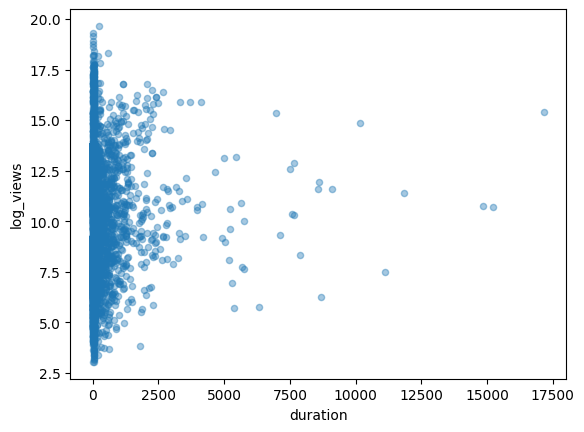

In [61]:
combined.plot(
    kind="scatter",
    x="duration",
    y="log_views",
    alpha=0.4
)



<Axes: xlabel='duration', ylabel='engagement_rate'>

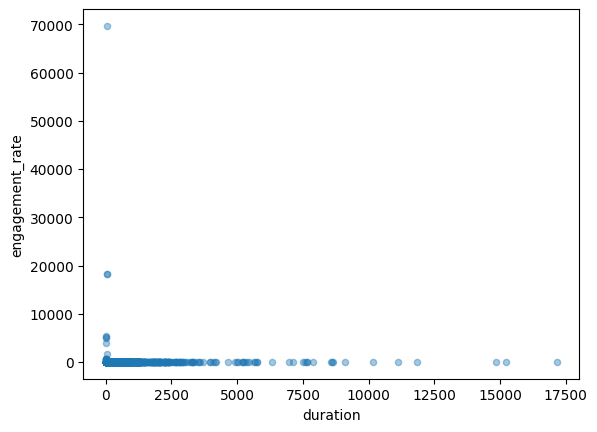

In [63]:
combined.plot(
    kind="scatter",
    x="duration",
    y="engagement_rate",
    alpha=0.4
)



## Cutting down
Short: < 60 seconds

Medium: 60–300 seconds (1–5 minutes)

Long: > 5 minutes

In [65]:
combined["length_category"] = pd.cut(
    combined["duration"],
    bins=[0, 60, 300, np.inf],
    labels=["Short", "Medium", "Long"]
)
combined

,video_id,views,likes,duration,platform,log_views,log_likes,engagement_rate,length_category
0,7017666017,343296.0,19425.0,59,tiktok,12.746351,9.874368,5.658382,Short
1,4014381136,140877.0,77355.0,32,tiktok,11.855650,11.256173,54.909602,Short
2,9859838091,902185.0,97690.0,31,tiktok,13.712576,11.489565,10.828156,Short
3,1866847991,437506.0,239954.0,25,tiktok,12.988848,12.388207,54.845876,Short
4,7105231098,56167.0,34987.0,19,tiktok,10.936102,10.462760,62.291025,Short
...,...,...,...,...,...,...,...,...,...
21102,snEgQDd5pCU,275866.0,24308.0,350,random,12.527674,10.098602,8.811524,Long
21103,vq5HQwnHKMo,448.0,19.0,809,random,6.107023,2.995732,4.241071,Long
21104,0iFP2zV3lCw,41950.0,188.0,293,random,10.644258,5.241747,0.448153,Medium
21105,NDPp_asmdFg,229.0,6.0,611,random,5.438079,1.945910,2.620087,Long


In [66]:
combined["length_category"].value_counts()


,count
length_category,
Short,19869
Long,773
Medium,464


In [69]:
# Median Views by length category
combined.groupby("length_category")["views"].median()

/tmp/ipython-input-560271293.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  combined.groupby("length_category")["views"].median()


,views
length_category,
Short,18462.0
Medium,19327.0
Long,26977.0


## Updated Graphs

<Axes: title={'center': 'log_views'}, xlabel='length_category'>

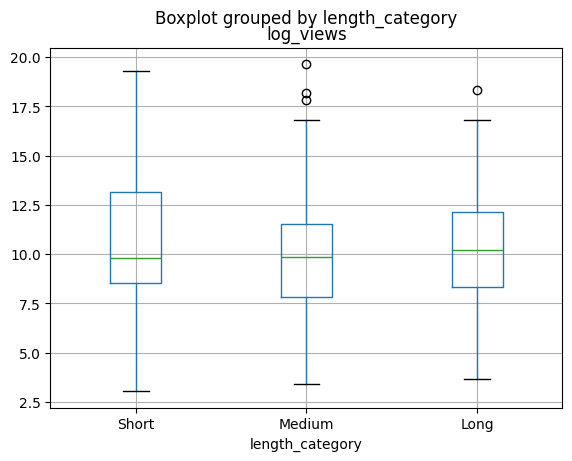

In [70]:
combined.boxplot(column="log_views", by="length_category")

<Axes: title={'center': 'log_likes'}, xlabel='length_category'>

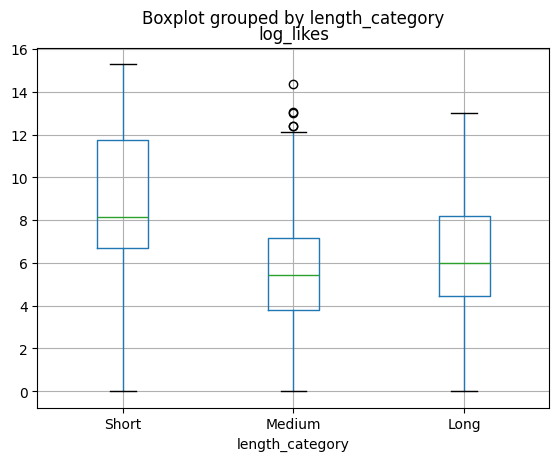

In [71]:
combined.boxplot(column="log_likes", by="length_category")

<Axes: title={'center': 'engagement_rate'}, xlabel='length_category'>

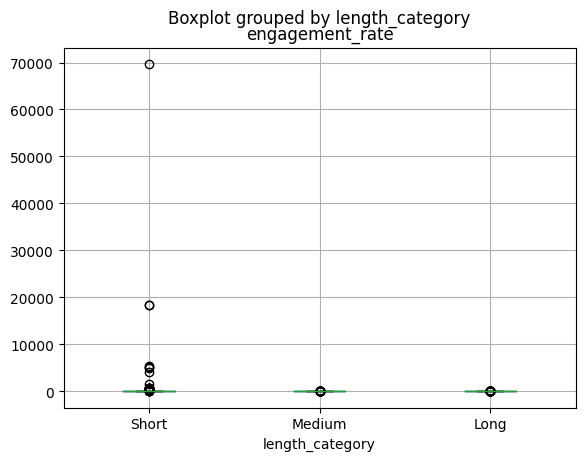

In [72]:
combined.boxplot(column="engagement_rate", by="length_category")

<Axes: title={'center': 'engagement_rate'}, xlabel='length_category'>

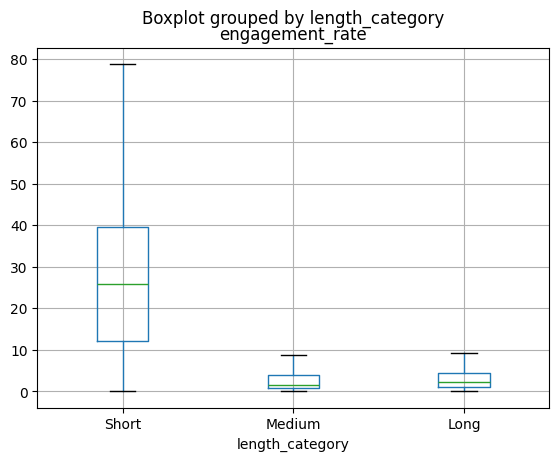

In [73]:
combined.boxplot(
    column="engagement_rate",
    by="length_category",
    showfliers=False   # hides outliers visually
)
